In [6]:
import os
import requests
import time
import asyncio
from PIL import Image
import math
import io
from IPython.display import display

测试最大拼接数：

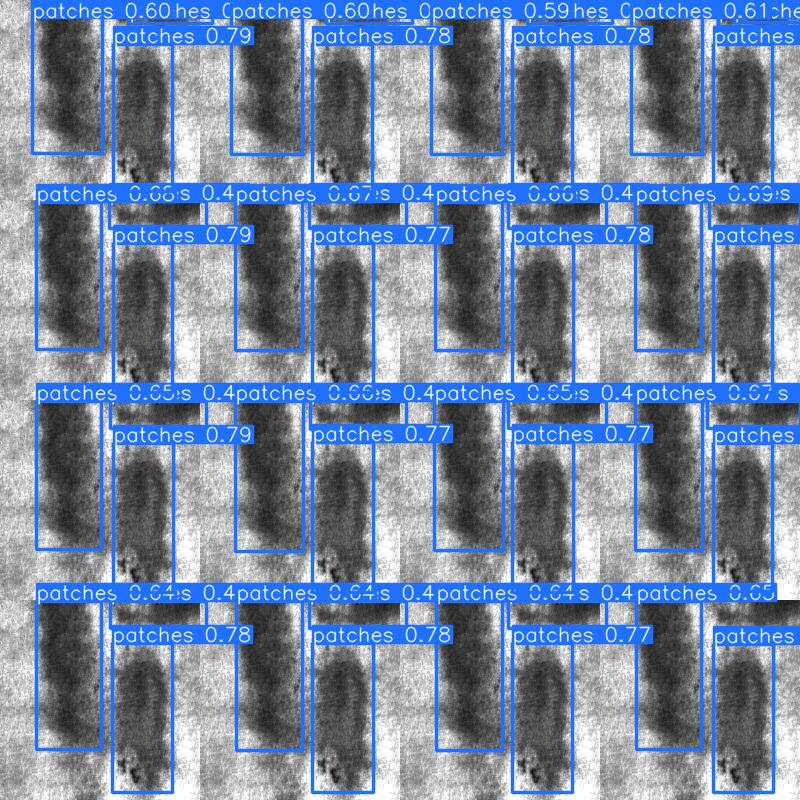

In [15]:
# 定义一个函数，用于计算排列后的行数和列数
def calculate_grid_size(num_images):
    size = int(math.sqrt(num_images))
    if size * size < num_images:
        size += 1
    return size

# 打开图片文件并添加到列表中
# 指定要加载的图像文件
image_file = r"F:\外包服务\毕设\基于机器视觉的表面缺陷检测方法\测试数据\patches_2.jpg"
# 指定要加载的图像文件数量
num_images = 16
# 创建包含重复文件路径的列表
image_files = [image_file] * num_images
# 加载图像文件
images = [Image.open(filename) for filename in image_files]

# 计算排列后的行数和列数
num_images = len(images)
grid_size = calculate_grid_size(num_images)

# 获取每个图片的尺寸
image_sizes = [image.size for image in images]
max_width = max([size[0] for size in image_sizes])
max_height = max([size[1] for size in image_sizes])

# 计算新图片的尺寸
new_size = (max_width * grid_size, max_height * grid_size)

# 创建一个新的空白图片，尺寸为拼接后的尺寸
new_image = Image.new("RGB", new_size)

# 将图片依次粘贴到新图片中
for index, image in enumerate(images):
    row = index // grid_size
    col = index % grid_size
    x_offset = col * max_width
    y_offset = row * max_height
    new_image.paste(image, (x_offset, y_offset))


url = "http://127.0.0.1:8010/detect/"

# 将图像转换为字节流
img_byte_array = io.BytesIO()
new_image.save(img_byte_array, format="JPEG")
img_byte_array.seek(0)

# 发送POST请求
files = {"image_file": img_byte_array}
response = requests.post(url, files=files)

pil_image = Image.open(io.BytesIO(response.content))

# 显示拼接后的图片
display(pil_image)

测试经典请求的执行时间：

In [20]:
import os
import io
import requests
from PIL import Image
import time

# 1. 计时器开始
start_time = time.time()

# 2. 读取指定文件夹内的所有文件
folder_path = "./NEU/train/images/"
image_files = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, file))]

# 3. 指定保存图像的文件夹
save_folder = "./normal_images/"

def process_image(image_file):
    url = "http://127.0.0.1:8010/detect/"
    with Image.open(image_file) as img:
        # 将图像转换为字节流
        img_byte_array = io.BytesIO()
        img.save(img_byte_array, format=img.format)
        img_byte_array.seek(0)

        # 发送POST请求
        files = {"image_file": img_byte_array}
        response = requests.post(url, files=files)

        # 保存处理后的图像到指定文件夹
        with open(os.path.join(save_folder, os.path.basename(image_file)), "wb") as f:
            f.write(response.content)

# 依次处理每张图片
for image_file in image_files:
    process_image(image_file)

# 1. 计时器结束
end_time = time.time()

# 计算总耗时
total_time = end_time - start_time
print("总耗时：", total_time)


总耗时： 249.52456307411194


In [21]:
# 计时器开始
start_time = time.time()

# 读取指定文件夹内的所有文件
folder_path = "./NEU/train/images/"
image_files = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, file))]

# 指定保存图像的文件夹
save_folder = "./splicing_images/"

# 定义一个函数，用于计算排列后的行数和列数
def calculate_grid_size(num_images):
    size = int(math.sqrt(num_images))
    if size * size < num_images:
        size += 1
    return size

# 加载图像文件
def load_images(folder_path, start_index, max_count):
    images = []
    filenames = []
    for filename in os.listdir(folder_path)[start_index:start_index + max_count]:
        try:
            image = Image.open(os.path.join(folder_path, filename))
            images.append(image)
            filenames.append(filename)
        except IOError:
            print("Error loading image:", filename)
    return images, filenames

# 处理图像函数
def process_images(images, filenames, save_folder):
    num_images_loaded = len(images)
    grid_size = calculate_grid_size(num_images_loaded)
    image_sizes = [image.size for image in images]
    max_width = max(size[0] for size in image_sizes)
    max_height = max(size[1] for size in image_sizes)
    new_size = (max_width * grid_size, max_height * grid_size)
    new_image = Image.new("RGB", new_size)
    image_positions = []
    bbox_info = []  # 新增用于记录bbox信息的列表
    for index, image in enumerate(images):
        row = index // grid_size
        col = index % grid_size
        x_offset = col * max_width
        y_offset = row * max_height
        new_image.paste(image, (x_offset, y_offset))
        image_positions.append((x_offset, y_offset))

        # 记录bbox信息
        bbox_info.append((x_offset, y_offset, x_offset + max_width, y_offset + max_height))

    img_byte_array = io.BytesIO()
    new_image.save(img_byte_array, format="JPEG")
    img_byte_array.seek(0)

    url = "http://127.0.0.1:8010/detect/"
    files = {"image_file": img_byte_array}
    response = requests.post(url, files=files)
    pil_image = Image.open(io.BytesIO(response.content))

    for i, bbox in enumerate(bbox_info):
        x1, y1, x2, y2 = bbox
        cropped_image = pil_image.crop((x1, y1, x2, y2))
        filename = filenames[i]  # 使用原始文件名
        save_path = os.path.join(save_folder, filename)
        cropped_image.save(save_path)


# 每次拼接的最大图像数量
max_images_per_round = 9

# 获取文件夹中所有图像文件的文件名
image_files = os.listdir(folder_path)

# 计算图像文件数量
num_images = len(image_files)

# 发送图像的起始索引
start_index = 0

while start_index < num_images:
    # 加载图像文件，每次最多加载max_images_per_round张
    images, filenames = load_images(folder_path, start_index, max_images_per_round)
    process_images(images, filenames, save_folder)
    start_index += max_images_per_round

# 计时器结束
end_time = time.time()

# 计算总耗时
total_time = end_time - start_time
print("总耗时：", total_time)

总耗时： 39.47669529914856
